# Evaluating RIANN on a recorded dataset

This notebook downloads one trial of the
[BROAD dataset](https://github.com/dlaidig/broad) on demand, estimates the
attitude with `RIANN`, and plots the orientation error against the optical
ground truth. If the download fails (e.g. offline), it falls back to synthetic
data with a known reference so the notebook still runs end-to-end.

> Data: Berlin Robust Orientation Estimation Assessment Dataset (BROAD),
> Laidig et al., *Data* 2021, <https://doi.org/10.3390/data6070072> —
> licensed CC-BY-4.0. The trial is downloaded unmodified into a local cache.

In [1]:
import urllib.request
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

from riann import RIANN

TRIAL = "01_undisturbed_slow_rotation_A.hdf5"
URL = "https://raw.githubusercontent.com/dlaidig/broad/main/data_hdf5/" + TRIAL

## Load the data

`download_trial` caches the file under `downloads/` (gitignored) and returns
`None` if it cannot be fetched, in which case we generate synthetic data.

In [2]:
def download_trial():
    """Download one BROAD trial into a local cache; return its path or None."""
    root = next((p for p in Path.cwd().parents if (p / "pyproject.toml").exists()), Path.cwd())
    dest = root / "downloads" / "broad" / TRIAL
    if dest.exists():
        return dest
    dest.parent.mkdir(parents=True, exist_ok=True)
    try:
        print(f"Downloading {TRIAL} ...")
        urllib.request.urlretrieve(URL, dest)
        return dest
    except OSError as exc:
        print(f"Download failed ({exc}); using synthetic data.")
        dest.unlink(missing_ok=True)
        return None


def load_trial(path):
    """Read acc, gyr, reference quaternions (w,x,y,z) and sampling rate."""
    with h5py.File(path, "r") as f:
        acc = f["imu_acc"][:]
        gyr = f["imu_gyr"][:]
        ref = f["opt_quat"][:]
        # sampling_rate may be stored as an attribute or as a dataset.
        fs = f.attrs["sampling_rate"] if "sampling_rate" in f.attrs else f["sampling_rate"][()]
    return acc, gyr, ref, float(np.ravel(fs)[0])


def synthetic_trial(fs=200.0, duration=15.0, g=9.81):
    """Synthetic y-axis tilt with ground-truth quaternions (offline fallback)."""
    n = int(fs * duration)
    t = np.linspace(0, duration, n, endpoint=False)
    rate = np.where((t > 2) & (t < 4), 0.5, 0.0)  # rad/s about +y: a brief tilt, then hold
    angle = np.cumsum(rate) / fs
    gyr = np.zeros((n, 3))
    gyr[:, 1] = rate + np.random.normal(0, 0.005, n)
    # Gravity expressed in the sensor frame for a sensor-to-earth y-rotation.
    acc = np.stack([-g * np.sin(angle), np.zeros(n), g * np.cos(angle)], axis=1)
    acc += np.random.normal(0, 0.05, acc.shape)
    ref = np.zeros((n, 4))
    ref[:, 0], ref[:, 2] = np.cos(angle / 2), np.sin(angle / 2)
    return acc, gyr, ref, fs

In [3]:
path = download_trial()
if path is not None:
    acc, gyr, ref_quat, fs = load_trial(path)
    source = TRIAL
else:
    acc, gyr, ref_quat, fs = synthetic_trial()
    source = "synthetic data"
print(f"Using {source}: {len(acc)} samples at {fs:g} Hz")

Using 01_undisturbed_slow_rotation_A.hdf5: 56940 samples at 285.714 Hz


## Estimate the attitude

In [4]:
riann = RIANN()
est_quat = riann.predict(acc, gyr, fs)

## Compare against the reference

Both `RIANN` and BROAD use scalar-first `(w, x, y, z)` quaternions with a
gravity-aligned earth frame. We compare via the earth-relative error
quaternion `est · inv(ref)` and report the **inclination** error: since RIANN
uses no magnetometer, absolute heading (yaw) is not observable, so the total
error also includes a heading component that is expected to drift.

Inclination error: mean 0.56°, max 3.92°
Total error:       mean 77.97°, max 180.00°


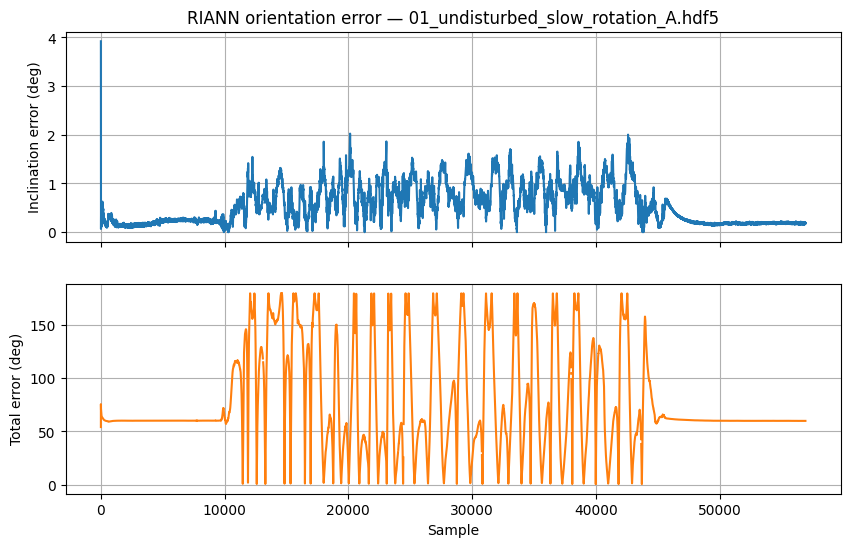

In [5]:
def attitude_error_deg(est, ref):
    """Earth-relative (total, inclination) error per sample, in degrees."""
    est = est / np.linalg.norm(est, axis=1, keepdims=True)
    ref = ref / np.linalg.norm(ref, axis=1, keepdims=True)
    ew, ex, ey, ez = est.T
    rw, rx, ry, rz = (ref * [1, -1, -1, -1]).T  # ref * [1,-1,-1,-1] = inverse
    w = np.abs(ew * rw - ex * rx - ey * ry - ez * rz)
    z = ew * rz + ex * ry - ey * rx + ez * rw
    total = np.degrees(2 * np.arccos(np.clip(w, 0, 1)))
    incl = np.degrees(2 * np.arccos(np.clip(np.sqrt(w**2 + z**2), 0, 1)))
    return total, incl


total, incl = attitude_error_deg(est_quat, ref_quat)
# Optical dropouts leave NaN gaps in the reference, so skip them in the stats.
print(f"Inclination error: mean {np.nanmean(incl):.2f}°, max {np.nanmax(incl):.2f}°")
print(f"Total error:       mean {np.nanmean(total):.2f}°, max {np.nanmax(total):.2f}°")

# Separate subplots: total error (incl. unobservable heading) dwarfs inclination.
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
ax1.plot(incl)
ax1.set_ylabel("Inclination error (deg)")
ax1.set_title(f"RIANN orientation error — {source}")
ax1.grid(True)
ax2.plot(total, color="tab:orange")
ax2.set_ylabel("Total error (deg)")
ax2.set_xlabel("Sample")
ax2.grid(True)
plt.show()